In [2]:
import decode
import decode.utils
import decode.neuralfitter.train.live_engine
from decode.generic import EmitterSet


import torch
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
import tifffile

# ------------ Data generation parameters  --------------
MONTE_CARLO_SAMPLES = 10
PSFW = 2
WIDTH = 50
HEIGTH = 50
BCKG = 3
UPSCALE = 4
DEG = np.pi/180.
THETA_STEP = 45*DEG
snrs = 50

# ------------ Helper functions  --------------
param = decode.utils.param_io.load_params('notebook_training_new_snr_50.yaml') 
simulator, sim_test = decode.neuralfitter.train.live_engine.setup_random_simulation(param)
camera = decode.simulation.camera.Photon2Camera.parse(param)
# param = decode.utils.param_io.autoset_scaling(param)


int

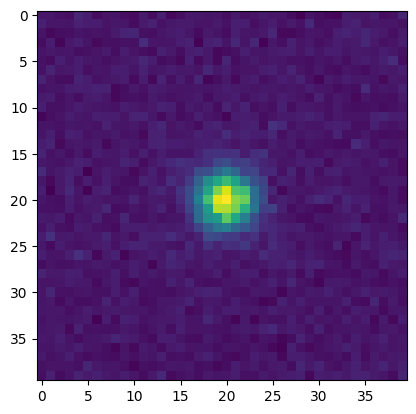

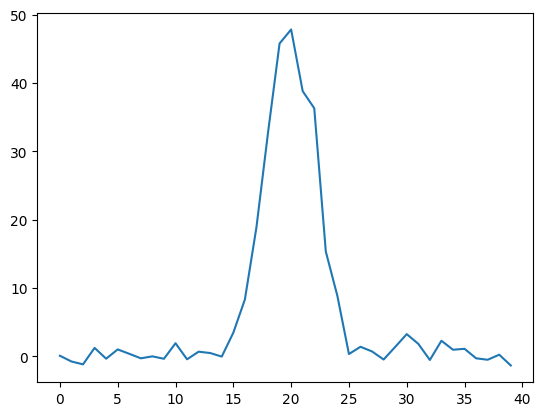

47.83368

In [9]:
def estim_snr(frame, plot=False):
    #assume centered emitter
    cut = frame[20]
    bckg = frame[0:10,0:10]
    bstd = np.std(bckg.ravel())
    bmu = np.mean(bckg.ravel())
    peak = np.max(cut)
    snr = (peak-bmu)/(bstd)
    if plot:
        plt.plot((cut-bmu)/bstd)
        plt.show()
    return snr
    
#my frame of 1 emitter
inten = param.Simulation.intensity_mu_sig[0]
xyz = torch.tensor([[20,20,0]], dtype=torch.float32)
photons = torch.tensor([inten])
frame_ix = torch.tensor([0], dtype=torch.int32, device='cpu')
emid = torch.tensor([0], dtype=torch.int32)
emprob = torch.tensor([1])
embckg = torch.tensor([150])
emset = EmitterSet(xyz, photons, frame_ix, emid, emprob, embckg, xy_unit='px', px_size=60)
simframe, bckg = simulator.forward(emset)
n_simframe = simframe.detach().cpu().numpy()[0]

plt.imshow(n_simframe)
plt.show()
estim_snr(n_simframe, plot=True)
# plt.matshow(n_simframe)
# plt.colorbar()

In [18]:
simulator.psf.img_shape

[40, 40]

In [131]:
device = 'cuda:0'  # or 'cpu'
worker = 4
path = 'run_200/2025-10-15_11-55-45_002.cluster.qolo/'
param_path = path+'param_run.yaml'
model_path = path+'model_0.pt'

param = decode.utils.param_io.load_params(param_path)
model = decode.neuralfitter.models.SigmaMUNet.parse(param)
model = decode.utils.model_io.LoadSaveModel(model,
                                            input_file=model_path,
                                            output_file=None).load_init(device=device)

frame_proc = decode.neuralfitter.utils.processing.TransformSequence([
    decode.neuralfitter.frame_processing.AutoCenterCrop(8),
    decode.neuralfitter.scale_transform.AmplitudeRescale.parse(param)
])

# Setup post-processing
# It's a sequence of backscaling, relative to abs. coord conversion and frame2emitter conversion
frames = torch.rand((10,50,50))
size_procced = decode.neuralfitter.frame_processing.get_frame_extent(frames.unsqueeze(1).size(), frame_proc.forward)  # frame size after processing
frame_extent = ((-0.5, size_procced[-2] - 0.5), (-0.5, size_procced[-1] - 0.5))


post_proc = decode.neuralfitter.utils.processing.TransformSequence([
    decode.neuralfitter.scale_transform.InverseParamListRescale.parse(param),
    decode.neuralfitter.coord_transform.Offset2Coordinate(xextent=frame_extent[0],
                                                          yextent=frame_extent[1],
                                                          img_shape=size_procced[-2:]),
    decode.neuralfitter.post_processing.SpatialIntegration(raw_th=0.1,
                                                          xy_unit='px',
                                                          px_size=param.Camera.px_size)
])
#instantiate predictor object
infer = decode.neuralfitter.Infer(model=model, ch_in=param.HyperParameter.channels_in,
                                  frame_proc=frame_proc, post_proc=post_proc,
                                  device=device, num_workers=worker)


def em_to_xyi(em_obj):
    xyz = em_obj.xyz
    phot = em_obj.phot
    print(len(xyz), 'em')
    xyi = np.zeros((xyz.shape[0], 3))
    xyi[:,0:2] = xyz[:,0:2]
    xyi[:,2] = phot
    xyi[:,0] += 0.5
    xyi[:,1] += 0.5
    return xyi

Model instantiated.
Model SHA-1 hash: fc02821a961cdfba3bfea8a5c513c9ee0a42e267
Loaded pretrained model: run_200/2025-10-15_11-55-45_002.cluster.qolo/model_0.pt


42500


100%|█████████████████████████████████████████████████████████████████████████████████████| 1/1 [00:00<00:00,  3.08it/s]


15 em


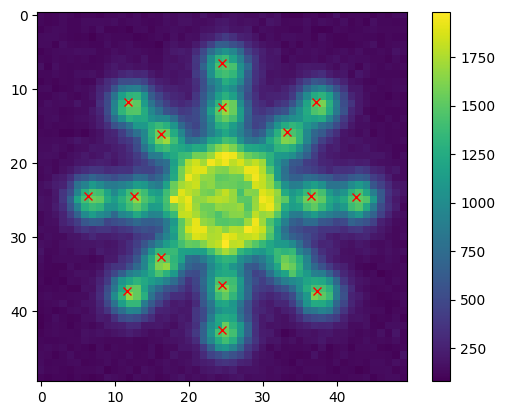

In [132]:
simulator.psf.xextent = [-0.5, 49.5]
simulator.psf.yextent = [-0.5, 49.5]
simulator.psf.img_shape = [50, 50]

xys_n = np.array([(25, 25,0)]+[(r*np.cos(THETA_STEP*i)+25, r*np.sin(THETA_STEP*i)+25,0)
               for i in range(8) for r in [6, 12, 18]])
n_em = len(xys_n)

inten = param.Simulation.intensity_mu_sig[0]
print(inten)
xyz = torch.tensor(xys_n, dtype=torch.float32)
photons = torch.tensor([inten]*n_em)
frame_ix = torch.tensor([0]*n_em, dtype=torch.int32, device='cpu')
emid = torch.tensor(list(range(n_em)), dtype=torch.int32)
emprob = torch.tensor([1]*n_em)
embckg = torch.tensor([150]*n_em)
emset = EmitterSet(xyz, photons, frame_ix, emid, emprob, embckg, xy_unit='px', px_size=60)
simframe, bckg = simulator.forward(emset)
n_simframe = simframe.detach().cpu().numpy()[0]

frames = torch.from_numpy(n_simframe.astype(np.float32).reshape((1,50,50)))

emset2 = infer.forward(frames)
xy = em_to_xyi(emset2)
plt.imshow(frames[0])
plt.colorbar()
plt.plot(xy[:,0], xy[:,1], "rx")
plt.show()



In [133]:

def gauss_2d(xy, amplitude, xo, yo, sigma_x, sigma_y, theta, offset):
    """
    Computes a 2D Gaussian function.

    Parameters:
        xy (tuple of ndarray): A tuple containing two 2D arrays (x, y) representing the grid coordinates.
        amplitude (float): The amplitude (peak value) of the Gaussian function.
        xo (float): The x-coordinate of the center of the Gaussian.
        yo (float): The y-coordinate of the center of the Gaussian.
        sigma_x (float): The standard deviation of the Gaussian in the x-direction.
        sigma_y (float): The standard deviation of the Gaussian in the y-direction.
        theta (float): The rotation angle of the Gaussian in radians.
        offset (float): The constant offset added to the Gaussian function.

    Returns:
        ndarray: A 1D array representing the raveled 2D Gaussian function values.
        It need to be reshaped to form a 2D array.
    """
    x, y = xy
    xo = float(xo)
    yo = float(yo)
    a = (np.cos(theta)**2)/(2*sigma_x**2) + (np.sin(theta)**2)/(2*sigma_y**2)
    b = -(np.sin(2*theta))/(4*sigma_x**2) + (np.sin(2*theta))/(4*sigma_y**2)
    c = (np.sin(theta)**2)/(2*sigma_x**2) + (np.cos(theta)**2)/(2*sigma_y**2)
    g = offset + amplitude*np.exp(- (a*((x-xo)**2) + 2*b*(x-xo)*(y-yo)
                                     + c*((y-yo)**2)))
    return g.ravel()


def generate_image(xyi, noise_mean, noise_std, psf_width, h, w):
    """
    Generates a 2D image with Gaussian point sources and added noise.

    Args:
        xyi (list of tuples): A list of tuples where each tuple contains 
            (x, y, intensity) representing the coordinates and intensity 
            of a point source.
        noise_mean (float): The mean of the Gaussian noise to be added to the image.
        noise_std (float): The standard deviation of the Gaussian noise.
        psf_width (float): The width of the point spread function (PSF) for the Gaussian sources.
        h (int): The height of the generated image.
        w (int): The width of the generated image.

    Returns:
        numpy.ndarray: A 2D array representing the generated image, normalized 
        such that all pixel values sum to 1.
    """
    # img = np.clip(RNG.normal(noise_mean, noise_std,
    #               h*w).reshape(h, w), 0, None)
    img = np.random.normal(noise_mean, noise_std,
                   h*w).reshape(h, w)
    ys = np.arange(h)
    xs = np.arange(w)
    xy = np.meshgrid(xs, ys)
    for x, y, intensity in xyi:
        img += gauss_2d(xy, intensity, x, y, psf_width,
                        psf_width, 0, 0).reshape((h, w))
    return img


100%|█████████████████████████████████████████████████████████████████████████████████████| 1/1 [00:00<00:00,  2.89it/s]


16 em


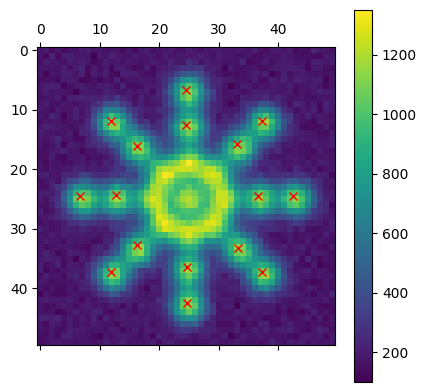

In [134]:
snr = 200
bckg_mu = 125
bckg_sigma = 25


def rescale_to_training_range(img, scale, offset):
    
    return (img*scale) + offset
    
def rescale_to_training_range2(img, orig_snr, orig_sigma, orig_offset):
    mxm = np.max(img)
    return (img*orig_snr*orig_sigma/mxm) + orig_offset    

xyis = np.array([(25, 25, pwr)]+[(r*np.cos(THETA_STEP*i)+25, r*np.sin(THETA_STEP*i)+25, pwr)
               for i in range(8) for r in [6, 12, 18]])
imtest = generate_image(xyis, bckg_mu, bckg_sigma, 2, 50, 50)
nimtest = (imtest - np.min(imtest))/np.sum((imtest - np.min(imtest)))
rimtest = rescale_to_training_range2(nimtest, 50, 25, 100)


frames = torch.from_numpy(rimtest.astype(np.float32).reshape((1,50,50)))
emset2 = infer.forward(frames)
xy = em_to_xyi(emset2)
plt.matshow(rimtest)
plt.colorbar()
plt.plot(xy[:,0], xy[:,1], "rx")
plt.show()
